<a target="_blank" href="https://colab.research.google.com/github/genomicsxai/alphagenome-pytorch/blob/main/examples/notebooks/alphagenome_pytorch_inference.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# AlphaGenome PyTorch: Forward Pass Example

This notebook demonstrates how to run a forward pass using the PyTorch implementation of AlphaGenome and visualize the predictions.

**Requirements:**
- PyTorch model weights (`model_all_folds.safetensors`) available from [HuggingFace](https://huggingface.co/gtca/alphagenome_pytorch)
- (Optional for comparison) DeepMind JAX model weights (`all_folds`) available from [Kaggle](https://www.kaggle.com/models/google/alphagenome)

To convert JAX weights to PyTorch format:
```bash
python scripts/convert_weights.py /path/to/jax-checkpoint --output model.pth
python scripts/extract_track_means.py --output track_means.pt
```

## Setup

In [1]:
# Uncomment the following to download the model to local dir:
# !hf download gtca/alphagenome_pytorch model_all_folds.safetensors --local-dir .

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import torch
import numpy as np
import matplotlib.pyplot as plt

from alphagenome_pytorch import AlphaGenome

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


## Configuration

Update these paths to point to your model weights and track means files.

In [2]:
# Update these paths
MODEL_WEIGHTS_PATH = '../../../weights/model_all_folds.safetensors'  # or your path to model weights

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Model

In [3]:
model = AlphaGenome.from_pretrained(MODEL_WEIGHTS_PATH)
model.cuda().eval()

print("Model loaded successfully!")

Model loaded successfully!


## Prepare Input Sequence

AlphaGenome expects one-hot encoded DNA sequences with shape `(batch, length, 4)` where channels represent A, C, G, T.

In [4]:
# Generate a random DNA sequence for demonstration
# In practice, you would load real genomic sequences
sequence_length = 1048576  # 1M bp (2^20)

# Random sequence: 0=A, 1=C, 2=G, 3=T
np.random.seed(42)
random_seq = np.random.randint(0, 4, size=(1, sequence_length))

# One-hot encode
dna_one_hot = np.eye(4)[random_seq]  # (1, length, 4)
dna_one_hot = torch.tensor(dna_one_hot, dtype=torch.bfloat16).to(device)

# Organism index: 0 = human, 1 = mouse
organism_index = torch.tensor([0], dtype=torch.long).to(device)

print(f"Input shape: {dna_one_hot.shape}")
print(f"Organism: Human (index={organism_index.item()})")

Input shape: torch.Size([1, 1048576, 4])
Organism: Human (index=0)


## Run Forward Pass

In [5]:
%%time
from alphagenome_pytorch.config import DtypePolicy
with torch.no_grad():
    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
        outputs = model(dna_one_hot.to(torch.bfloat16), organism_index)
print(f"\nAvailable output types: {list(outputs.keys())}")


Available output types: ['atac', 'dnase', 'procap', 'cage', 'rna_seq', 'chip_tf', 'chip_histone', 'contact_maps', 'splice_sites', 'splice_site_usage', 'splice_junctions']
CPU times: user 1.25 s, sys: 292 ms, total: 1.54 s
Wall time: 1.69 s


## Explore Outputs

Each output type has predictions at different resolutions (1bp and/or 128bp).

In [6]:
# Print output shapes
for name, out in outputs.items():
    if isinstance(out, dict):
        for res, tensor in out.items():
            print(f"{name}[{res}]: {tensor.shape}")
    elif isinstance(out, torch.Tensor):
        print(f"{name}: {out.shape}")
    else:
        print(f"{name}: {type(out)}")

atac[1]: torch.Size([1, 1048576, 256])
atac[128]: torch.Size([1, 8192, 256])
dnase[1]: torch.Size([1, 1048576, 384])
dnase[128]: torch.Size([1, 8192, 384])
procap[1]: torch.Size([1, 1048576, 128])
procap[128]: torch.Size([1, 8192, 128])
cage[1]: torch.Size([1, 1048576, 640])
cage[128]: torch.Size([1, 8192, 640])
rna_seq[1]: torch.Size([1, 1048576, 768])
rna_seq[128]: torch.Size([1, 8192, 768])
chip_tf[128]: torch.Size([1, 8192, 1664])
chip_histone[128]: torch.Size([1, 8192, 1152])
contact_maps: torch.Size([1, 512, 512, 28])
splice_sites[logits]: torch.Size([1, 1048576, 5])
splice_sites[probs]: torch.Size([1, 1048576, 5])
splice_site_usage[logits]: torch.Size([1, 1048576, 734])
splice_site_usage[predictions]: torch.Size([1, 1048576, 734])
splice_site_usage[track_mask]: torch.Size([1, 1, 734])
splice_junctions[pred_counts]: torch.Size([1, 512, 512, 734])
splice_junctions[splice_site_positions]: torch.Size([1, 4, 512])
splice_junctions[splice_junction_mask]: torch.Size([1, 512, 512, 734])

## Visualize Predictions

Let's plot some example track predictions.

In [8]:
def plot_tracks(outputs, track_names, resolution=128, window_size=1024, start=0, track_indices=None):
    """
    Plot genomic track predictions.
    
    Args:
        outputs: Model output dictionary
        track_names: List of track names to plot (e.g., ['atac', 'dnase'])
        resolution: Resolution to plot (1 or 128)
        window_size: Number of bins to show
        start: Starting bin position
        track_indices: Optional dict mapping track_name to indices to plot
    """
    n_tracks = len(track_names)
    fig, axes = plt.subplots(n_tracks, 1, figsize=(14, 3 * n_tracks), sharex=True)
    
    if n_tracks == 1:
        axes = [axes]
    
    end = start + window_size
    x = np.arange(start, end) * resolution  # Convert to bp
    
    for ax, name in zip(axes, track_names):
        if name not in outputs or resolution not in outputs[name]:
            ax.set_title(f"{name} (not available at {resolution}bp)")
            continue
            
        data = outputs[name][resolution][0, start:end, :].cpu().numpy()
        
        # Select which track indices to plot
        if track_indices and name in track_indices:
            idx = track_indices[name]
        else:
            # Plot mean across all tracks
            idx = None
        
        if idx is not None:
            for i in idx:
                ax.plot(x, data[:, i], alpha=0.7, label=f"Track {i}")
            ax.legend(loc='upper right', fontsize=8)
        else:
            # Plot mean and std
            mean = data.mean(axis=1)
            std = data.std(axis=1)
            ax.plot(x, mean, color='blue', alpha=0.8)
            ax.fill_between(x, mean - std, mean + std, alpha=0.3, color='blue')
        
        ax.set_ylabel(name.upper())
        ax.set_title(f"{name.upper()} predictions at {resolution}bp resolution")
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Position (bp)')
    plt.tight_layout()
    plt.show()

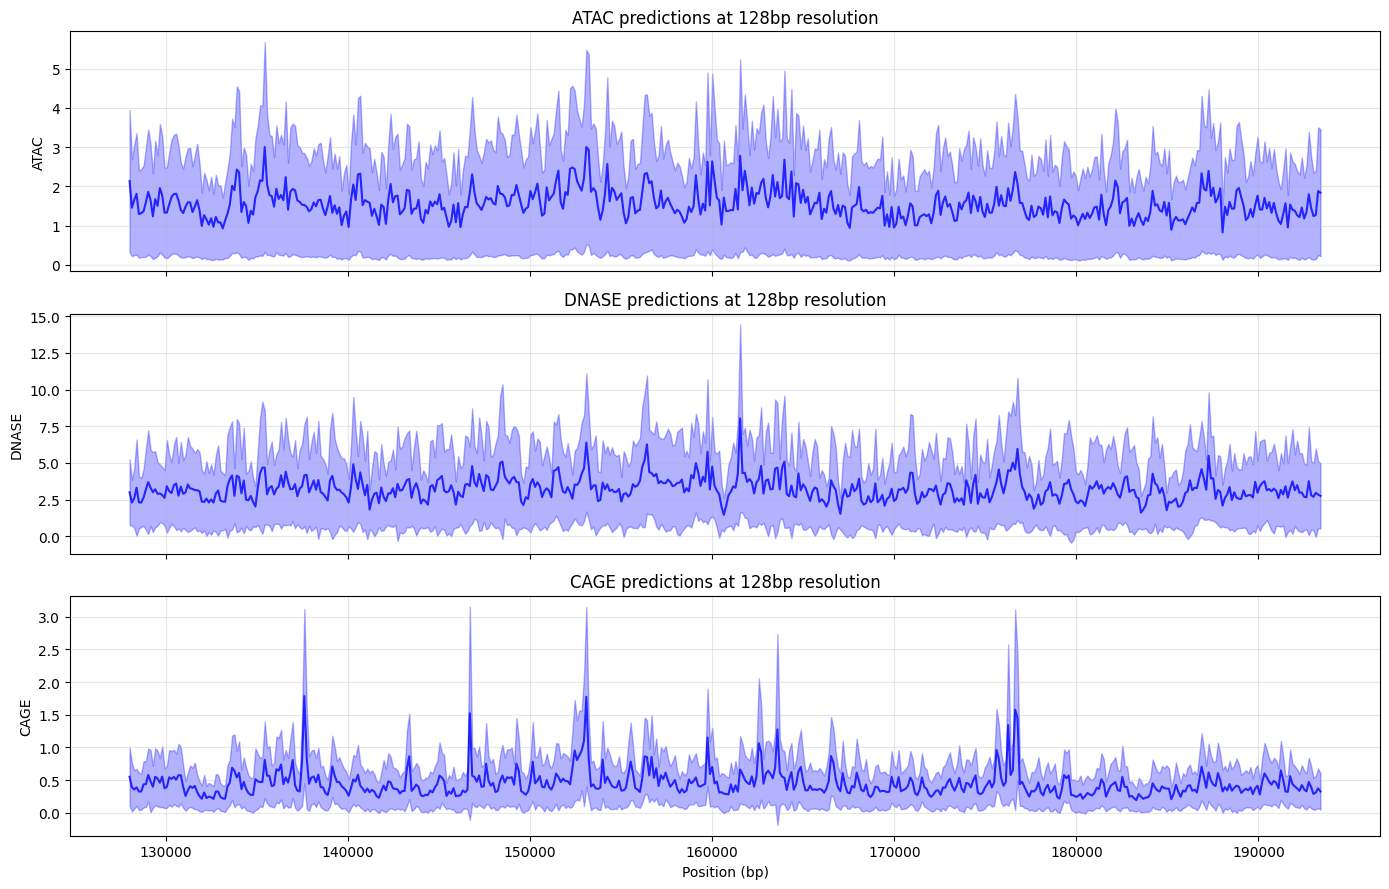

In [9]:
# Plot ATAC, DNase, and CAGE predictions at 128bp resolution
plot_tracks(
    outputs, 
    track_names=['atac', 'dnase', 'cage'],
    resolution=128,
    window_size=512,
    start=1000
)

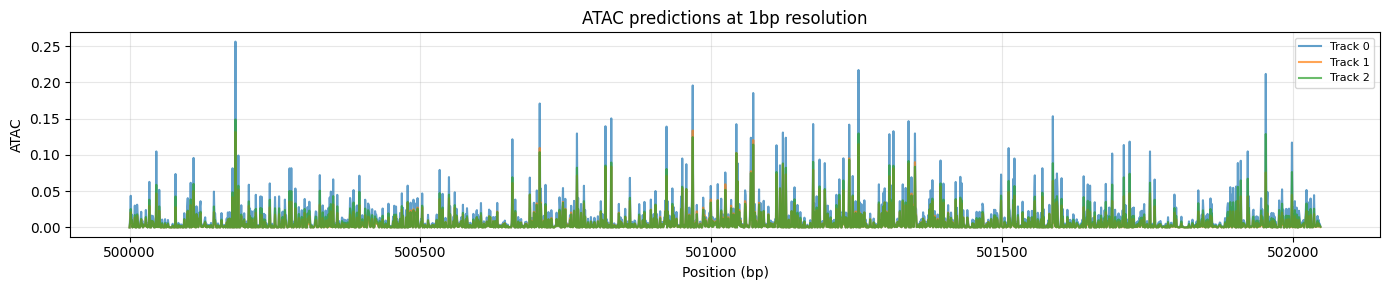

In [10]:
# Plot specific tracks at 1bp resolution
plot_tracks(
    outputs,
    track_names=['atac'],
    resolution=1,
    window_size=2048,
    start=500000,
    track_indices={'atac': [0, 1, 2]}  # Plot first 3 tracks
)

## RNA-seq Predictions

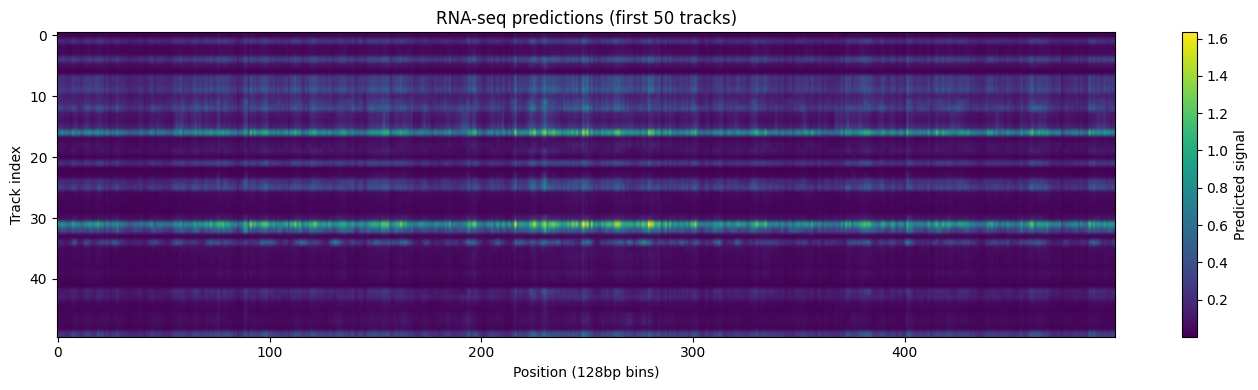

In [10]:
# RNA-seq has squashing applied (log1p-like transformation)
rna_seq_128bp = outputs['rna_seq'][128][0].cpu().numpy()

plt.figure(figsize=(14, 4))
plt.imshow(
    rna_seq_128bp.T[:50, 1000:1500],  # First 50 tracks, window of 500 bins
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='Predicted signal')
plt.xlabel('Position (128bp bins)')
plt.ylabel('Track index')
plt.title('RNA-seq predictions (first 50 tracks)')
plt.tight_layout()
plt.show()

## Contact Map Predictions

In [ ]:
# Contact/Hi-C predictions are 2D
if 'contact_maps' in outputs:
    contact_maps = outputs['contact_maps']
    
    # The contact map output has shape (B, S, S, num_tracks)
    # Plot the first track
    if isinstance(contact_maps, torch.Tensor):
        cm = contact_maps[0, :, :, 0].cpu().numpy()
    else:
        cm = contact_maps[128][0, :, :, 0].cpu().numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, cmap='RdBu_r', vmin=-2, vmax=2)
    plt.colorbar(label='Contact score')
    plt.title('Predicted contact map (track 0)')
    plt.xlabel('Position')
    plt.ylabel('Position')
    plt.tight_layout()
    plt.show()
else:
    print("Contact map predictions not available")

In [14]:
# Free GPU memory
import gc 

model.cpu()
del model
torch.cuda.empty_cache()
gc.collect()
print(f"PyTorch GPU freed. CUDA allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

NameError: name 'model' is not defined

## JAX Checkpoint Forward Pass

In [14]:
import jax
import jax.numpy as jnp
from pathlib import Path

from alphagenome_research.model import dna_model
from alphagenome_research.model.metadata import metadata as metadata_lib
from alphagenome.models import dna_output
from alphagenome.data import genome, track_data
from alphagenome.visualization import plot_components

In [15]:
JAX_WEIGHTS_PATH = "/scratch/m000097/abuen/personal/alphagenome-pytorch/ckpts/jax/all_folds/1"

dev = jax.devices()[0]
jax_model = dna_model.create(
    checkpoint_path=JAX_WEIGHTS_PATH,
    device=dev,
)
print("JAX model loaded")

/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


JAX model loaded


In [16]:
jax_organism = dna_model.Organism.HOMO_SAPIENS
jax_track_metadata = jax_model._metadata[jax_organism]

jax_input = dna_one_hot.cpu().numpy()  # (1, S, 4) numpy from the PyTorch tensor
jax_organism_index = jnp.array([0], dtype=jnp.int32)
jax_strand_reindexing = jax.device_put(jax_track_metadata.strand_reindexing)
jax_negative_strand_mask = jnp.array([False], dtype=bool)

print("Running JAX forward pass...")
jax_preds = jax_model._predict(
    jax_model._params,
    jax_model._state,
    jax.device_put(jax_input),
    jax_organism_index,
    negative_strand_mask=jax_negative_strand_mask,
    strand_reindexing=jax_strand_reindexing,
)
print("JAX prediction complete.")
print(f"JAX output types: {list(jax_preds.keys())}")

Running JAX forward pass...
JAX prediction complete.
JAX output types: [ATAC, CAGE, DNASE, RNA_SEQ, CHIP_HISTONE, CHIP_TF, SPLICE_SITES, SPLICE_SITE_USAGE, SPLICE_JUNCTIONS, CONTACT_MAPS, PROCAP]


## Compare PyTorch and JAX Predictions

In [17]:
from scipy.stats import pearsonr

COMPARISON_TRACKS = [
    (dna_output.OutputType.ATAC,         'atac',         1),
    (dna_output.OutputType.DNASE,        'dnase',        1),
    (dna_output.OutputType.CAGE,         'cage',         1),
    (dna_output.OutputType.RNA_SEQ,      'rna_seq',      1),
    (dna_output.OutputType.CHIP_TF,      'chip_tf',      128),
    (dna_output.OutputType.CHIP_HISTONE, 'chip_histone', 128),
    (dna_output.OutputType.PROCAP,       'procap',       1),
]

print(f"{'Track':<20s} {'Mean Pearson r':>14s} {'N tracks':>10s} {'PT shape':>20s} {'JAX shape':>20s}")
print("-" * 80)
for jax_key, pt_key, res in COMPARISON_TRACKS:
    pt_tensor = outputs[pt_key]
    if isinstance(pt_tensor, dict):
        pt_arr = pt_tensor[res][0].detach().float().cpu().numpy()
    else:
        pt_arr = pt_tensor[0].detach().float().cpu().numpy()

    jax_arr = np.array(jax_preds[jax_key])[0]

    min_len = min(pt_arr.shape[0], jax_arr.shape[0])
    min_tracks = min(pt_arr.shape[1], jax_arr.shape[1])

    corrs = []
    for t in range(min_tracks):
        pt_col = pt_arr[:min_len, t].astype(np.float64)
        jax_col = jax_arr[:min_len, t].astype(np.float64)
        valid = np.isfinite(pt_col) & np.isfinite(jax_col)
        if valid.sum() > 1:
            r, _ = pearsonr(pt_col[valid], jax_col[valid])
            corrs.append(r)
    mean_r = np.mean(corrs) if corrs else float('nan')

    print(f"{pt_key:<20s} {mean_r:14.5f} {len(corrs):10d} {str(pt_arr.shape):>20s} {str(jax_arr.shape):>20s}")

Track                Mean Pearson r   N tracks             PT shape            JAX shape
--------------------------------------------------------------------------------
atac                        0.99983        167       (1048576, 256)       (1048576, 256)
dnase                       0.99984        305       (1048576, 384)       (1048576, 384)
cage                        0.99927        546       (1048576, 640)       (1048576, 640)
rna_seq                     0.99817        667       (1048576, 768)       (1048576, 768)
chip_tf                     0.99885       1617         (8192, 1664)         (8192, 1664)
chip_histone                0.99864       1116         (8192, 1152)         (8192, 1152)
procap                      0.99951         12       (1048576, 128)       (1048576, 128)


For illustration, we plot the first three predicted JAX and PyTorch tracks overlaid for ATAC, DNAse, and CAGE.

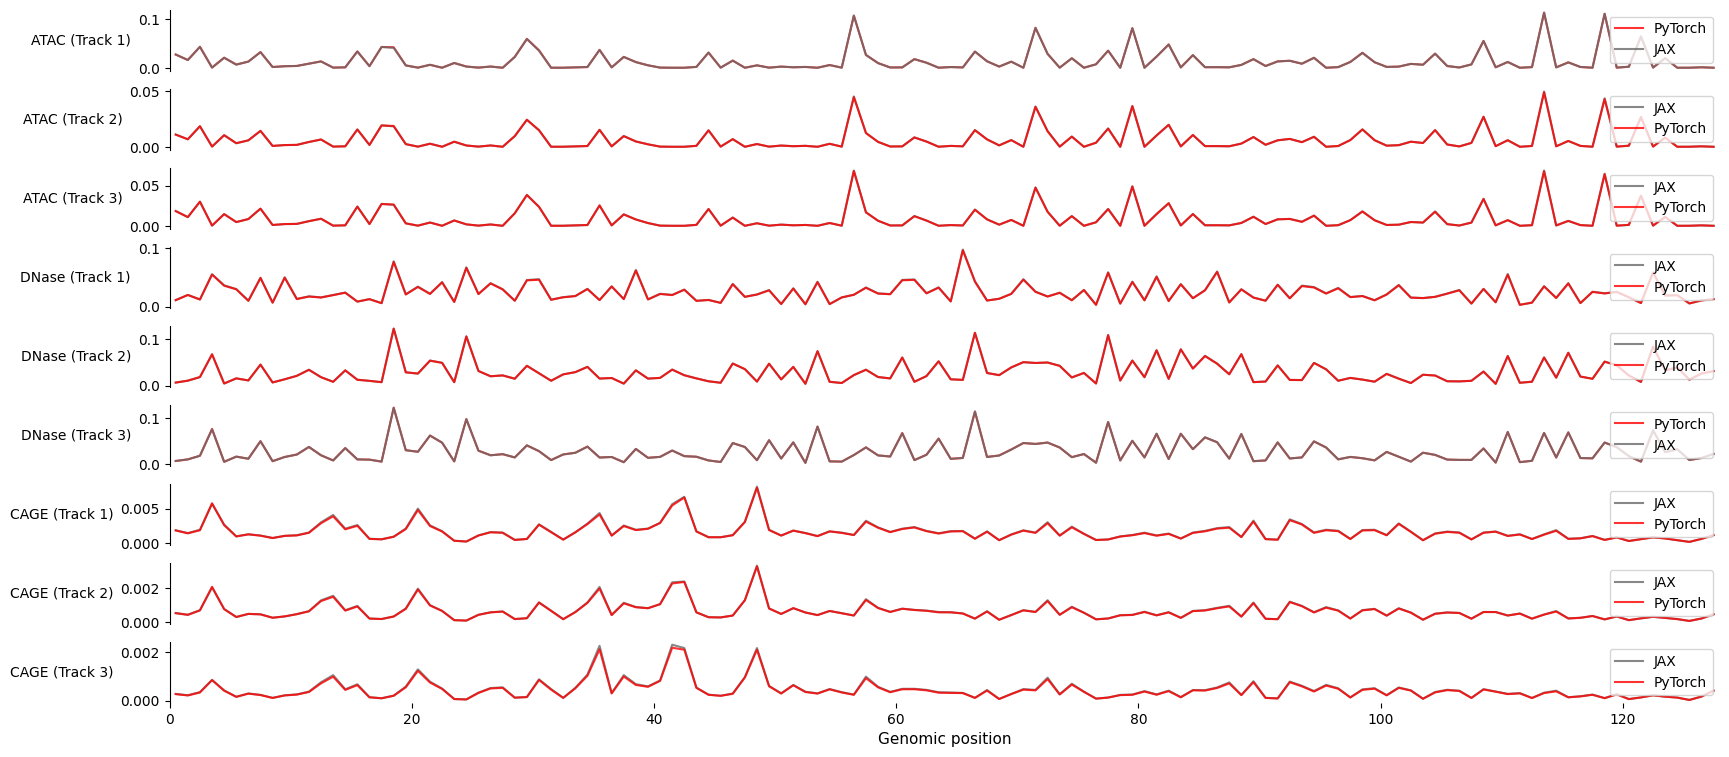

In [18]:
jax_metadata = metadata_lib.load(dna_model.Organism.HOMO_SAPIENS)
OVERLAY_TRACKS = [
    (dna_output.OutputType.ATAC,    'atac',    1,  'ATAC'),
    (dna_output.OutputType.DNASE,   'dnase',   1,  'DNase'),
    (dna_output.OutputType.CAGE,    'cage',    1,  'CAGE'),
]
dummy_interval = genome.Interval(chromosome='chr1', start=0, end=sequence_length)
plot_interval = genome.Interval(chromosome='chr1', start=0, end=2**7)

components = []
for jax_key, pt_key, res, label in OVERLAY_TRACKS:
    pt_tensor = outputs[pt_key]
    if isinstance(pt_tensor, dict):
        pt_arr = pt_tensor[res][0].detach().float().cpu().numpy()
    else:
        pt_arr = pt_tensor[0].detach().float().cpu().numpy()
    jax_arr = np.array(jax_preds[jax_key])[0]
    n_show = min(3, pt_arr.shape[1], jax_arr.shape[1])
    meta_df = getattr(jax_metadata, pt_key).iloc[:n_show].reset_index(drop=True)
    for i in range(n_show):
        single_meta = meta_df.iloc[i:i+1].reset_index(drop=True)
        pt_td = track_data.TrackData(
            values=pt_arr[:, i:i+1], resolution=res,
            metadata=single_meta, interval=dummy_interval,
        )
        jax_td = track_data.TrackData(
            values=jax_arr[:, i:i+1], resolution=res,
            metadata=single_meta, interval=dummy_interval,
        )
        components.append(plot_components.OverlaidTracks(
            tdata={'PyTorch': pt_td, 'JAX': jax_td},
            colors={'PyTorch': 'red', 'JAX': 'dimgrey'},
            ylabel_template=f'{label} (Track {i+1})',
        ))

fig = plot_components.plot(
    components=components,
    interval=plot_interval,
)
fig.axes[-1].set_xlabel('Genomic position', fontsize=11)
plt.show()

## Summary

This notebook demonstrated:
1. Loading the AlphaGenome PyTorch model and running a forward pass
2. Visualizing predictions for various track types (ATAC, DNase, CAGE, RNA-seq, ChIP, contact maps)
3. Loading the JAX (DeepMind) reference model and running the same input through it
4. Comparing PyTorch vs JAX outputs via Pearson correlation and overlaid track plots

For more advanced usage including variant effect prediction and in silico mutagenesis, see the other example notebooks.